In [1]:
# ==========================================================
# PENELITIAN SKRIPSI
# KLASIFIKASI PENYAKIT DAUN PADI
# EfficientNet-B6
# TensorFlow 2.x
# Google Colab Free
# ==========================================================

# ==========================================================
# SESI 1
# INSTALL LIBRARY
# ==========================================================

!pip -q install kaggle
!pip -q install opencv-python-headless
!pip -q install scikit-learn
!pip -q install matplotlib
!pip -q install seaborn

In [2]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import os
import gc
import cv2
import zipfile
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# CEK GPU
# ==========================================================

print("="*50)
print("TensorFlow :", tf.__version__)
print("="*50)

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:

    print("GPU Aktif")

    print(gpus)

else:

    print("GPU Tidak Ditemukan")

TensorFlow : 2.20.0
GPU Aktif
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ==========================================================
# MEMORY GROWTH
# ==========================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print("Memory Growth Aktif")

    except RuntimeError as e:

        print(e)

Memory Growth Aktif


In [5]:
# ==========================================================
# MIXED PRECISION
# ==========================================================

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [6]:
# ==========================================================
# RANDOM SEED
# ==========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

print("Seed :", SEED)

Seed : 42


In [7]:
# ==========================================================
# KONFIGURASI PENELITIAN
# ==========================================================

IMG_SIZE = 224

BATCH_SIZE = 2

EPOCHS = 25

NUM_CLASSES = 4

AUTOTUNE = tf.data.AUTOTUNE

print("="*50)
print("Image Size :", IMG_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Epoch :", EPOCHS)
print("Jumlah Kelas :", NUM_CLASSES)
print("="*50)

Image Size : 224
Batch Size : 2
Epoch : 25
Jumlah Kelas : 4


In [8]:
# ==========================================================
# BERSIHKAN MEMORY
# ==========================================================

gc.collect()

tf.keras.backend.clear_session()

print("SESI 1 SELESAI")

SESI 1 SELESAI


In [9]:
# ==========================================================
# SESI 2
# DOWNLOAD DATASET KAGGLE
# ==========================================================

from google.colab import files

print("Upload file kaggle.json")

files.upload()

Upload file kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"syukronnurfadillah","key":"f8e315c57cea073b9e94253ecfe408aa"}'}

In [10]:
# ==========================================================
# KONFIGURASI KAGGLE
# ==========================================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Konfigurasi Kaggle berhasil")

Konfigurasi Kaggle berhasil


In [11]:
# ==========================================================
# DOWNLOAD DATASET
# ==========================================================

!kaggle datasets download -d shayanriyaz/riceleafs

Dataset URL: https://www.kaggle.com/datasets/shayanriyaz/riceleafs
License(s): CC0-1.0
100% 14.9G/14.9G [02:12<00:00, 121MB/s]



In [12]:
# ==========================================================
# EKSTRAK DATASET
# ==========================================================

import zipfile

zip_path = "/content/riceleafs.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak")

Dataset berhasil diekstrak


In [13]:
# ==========================================================
# CEK STRUKTUR DATASET
# ==========================================================

for root, dirs, files in os.walk("/content/dataset"):

    print(root)

/content/dataset
/content/dataset/riceleafs
/content/dataset/riceleafs/RiceLeafs
/content/dataset/riceleafs/RiceLeafs/validation
/content/dataset/riceleafs/RiceLeafs/validation/LeafBlast
/content/dataset/riceleafs/RiceLeafs/validation/BrownSpot
/content/dataset/riceleafs/RiceLeafs/validation/Healthy
/content/dataset/riceleafs/RiceLeafs/validation/Hispa
/content/dataset/riceleafs/RiceLeafs/train
/content/dataset/riceleafs/RiceLeafs/train/LeafBlast
/content/dataset/riceleafs/RiceLeafs/train/BrownSpot
/content/dataset/riceleafs/RiceLeafs/train/Healthy
/content/dataset/riceleafs/RiceLeafs/train/Hispa
/content/dataset/RiceLeafs
/content/dataset/RiceLeafs/validation
/content/dataset/RiceLeafs/validation/LeafBlast
/content/dataset/RiceLeafs/validation/BrownSpot
/content/dataset/RiceLeafs/validation/Healthy
/content/dataset/RiceLeafs/validation/Hispa
/content/dataset/RiceLeafs/train
/content/dataset/RiceLeafs/train/LeafBlast
/content/dataset/RiceLeafs/train/BrownSpot
/content/dataset/RiceLeafs

In [14]:
# ==========================================================
# FOLDER DATASET
# ==========================================================

DATASET_PATH = "/content/dataset/RiceLeafs"

print(DATASET_PATH)

/content/dataset/RiceLeafs


In [15]:
# ==========================================================
# VALIDASI DATASET
# ==========================================================

assert os.path.exists(DATASET_PATH)

print("Folder ditemukan")

Folder ditemukan


In [16]:
gc.collect()

print("SESI 2 SELESAI")

SESI 2 SELESAI


In [17]:
# ==========================================================
# SESI 3
# MEMBACA DATASET
# ==========================================================

import os
import pandas as pd

image_paths = []
labels = []

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

for split in ["train", "validation"]:

    split_path = os.path.join(DATASET_PATH, split)

    if not os.path.exists(split_path):
        continue

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for file in os.listdir(class_path):

            if file.lower().endswith(VALID_EXTENSIONS):

                image_paths.append(
                    os.path.join(class_path, file)
                )

                labels.append(class_name)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Dataset berhasil dibaca.")

Dataset berhasil dibaca.


In [18]:
# ==========================================================
# TOTAL DATA
# ==========================================================

print("="*50)

print("Jumlah Dataset :", len(df))

print("="*50)

Jumlah Dataset : 3355


In [19]:
# ==========================================================
# DISTRIBUSI DATA
# ==========================================================

class_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
)

print(class_distribution)

label
BrownSpot     523
Healthy      1488
Hispa         565
LeafBlast     779
Name: count, dtype: int64


In [20]:
# ==========================================================
# CEK MISSING VALUE
# ==========================================================

print(df.isnull().sum())

filepath    0
label       0
dtype: int64


In [21]:
# ==========================================================
# VALIDASI FILE
# ==========================================================

broken = []

for path in df["filepath"]:

    if not os.path.exists(path):

        broken.append(path)

print("File rusak :", len(broken))

File rusak : 0


In [22]:
# ==========================================================
# LABEL ENCODER
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label_id"] = encoder.fit_transform(df["label"])

CLASS_NAMES = list(encoder.classes_)

NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)

print(NUM_CLASSES)

['BrownSpot', 'Healthy', 'Hispa', 'LeafBlast']
4


In [23]:
# ==========================================================
# INFORMASI DATASET
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3355 entries, 0 to 3354
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  3355 non-null   object
 1   label     3355 non-null   object
 2   label_id  3355 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 78.8+ KB


In [24]:
# ==========================================================
# SAMPLE DATA
# ==========================================================

df.head()

,filepath,label,label_id
0,/content/dataset/RiceLeafs/train/BrownSpot/IMG...,BrownSpot,0
1,/content/dataset/RiceLeafs/train/BrownSpot/IMG...,BrownSpot,0
2,/content/dataset/RiceLeafs/train/BrownSpot/IMG...,BrownSpot,0
3,/content/dataset/RiceLeafs/train/BrownSpot/IMG...,BrownSpot,0
4,/content/dataset/RiceLeafs/train/BrownSpot/IMG...,BrownSpot,0


In [25]:
# ==========================================================
# CLEAN MEMORY
# ==========================================================

gc.collect()

print("SESI 3 SELESAI")

SESI 3 SELESAI


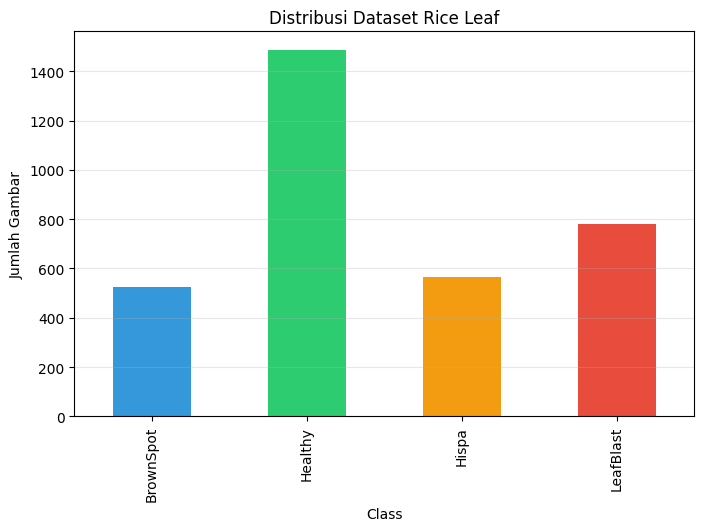

In [26]:
# ==========================================================
# SESI 4
# DISTRIBUSI DATASET
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

class_distribution.plot(
    kind="bar",
    color=["#3498db","#2ecc71","#f39c12","#e74c3c"]
)

plt.title("Distribusi Dataset Rice Leaf")

plt.xlabel("Class")

plt.ylabel("Jumlah Gambar")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [27]:
# ==========================================================
# PERSENTASE DATASET
# ==========================================================

percentage = (
    class_distribution /
    class_distribution.sum()
) * 100

print(
    percentage.round(2)
)

label
BrownSpot    15.59
Healthy      44.35
Hispa        16.84
LeafBlast    23.22
Name: count, dtype: float64


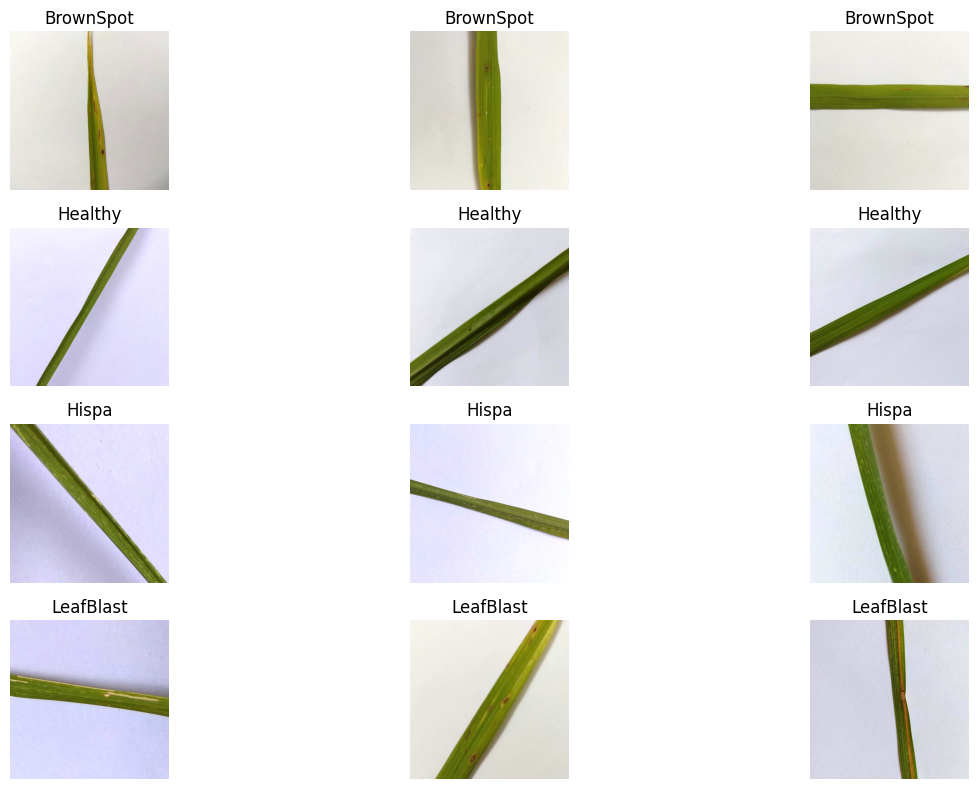

In [28]:
# ==========================================================
# CONTOH DATASET
# ==========================================================

import cv2

plt.figure(figsize=(14,8))

for i, kelas in enumerate(CLASS_NAMES):

    sample = df[
        df["label"]==kelas
    ].sample(
        3,
        random_state=42
    )

    for j,(idx,row) in enumerate(sample.iterrows()):

        image = cv2.imread(row["filepath"])

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(
            4,
            3,
            i*3+j+1
        )

        plt.imshow(image)

        plt.title(kelas)

        plt.axis("off")

plt.tight_layout()

plt.show()

In [29]:
# ==========================================================
# UKURAN GAMBAR
# ==========================================================

widths = []

heights = []

for path in df["filepath"]:

    img = cv2.imread(path)

    h,w = img.shape[:2]

    widths.append(w)

    heights.append(h)

In [30]:
# ==========================================================
# STATISTIK UKURAN GAMBAR
# ==========================================================

resolution_df = pd.DataFrame({

    "Width":widths,

    "Height":heights

})

resolution_df.describe()

,Width,Height
count,3355.000000,3355.000000
mean,2049.852757,2049.851565
std,607.889970,607.890651
min,734.000000,734.000000
25%,1604.500000,1604.500000
50%,1918.000000,1918.000000
75%,2363.000000,2363.000000
max,3120.000000,3120.000000


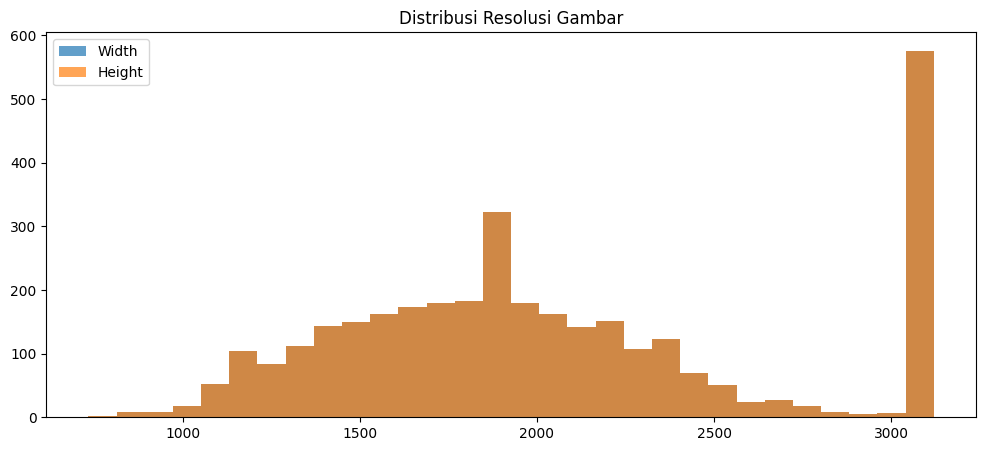

In [31]:
# ==========================================================
# HISTOGRAM RESOLUSI
# ==========================================================

plt.figure(figsize=(12,5))

plt.hist(
    widths,
    bins=30,
    alpha=0.7,
    label="Width"
)

plt.hist(
    heights,
    bins=30,
    alpha=0.7,
    label="Height"
)

plt.legend()

plt.title("Distribusi Resolusi Gambar")

plt.show()

In [32]:
print("Width Minimum :", min(widths))
print("Height Minimum :", min(heights))

Width Minimum : 734
Height Minimum : 734


In [33]:
print("Width Maksimum :", max(widths))
print("Height Maksimum :", max(heights))

Width Maksimum : 3120
Height Maksimum : 3120


In [34]:
# ==========================================================
# CLEAN MEMORY
# ==========================================================

del widths

del heights

gc.collect()

print("SESI 4 SELESAI")

SESI 4 SELESAI


In [35]:
# ==========================================================
# SESI 5
# PIPELINE TENSORFLOW FINAL
# ==========================================================

from tensorflow.keras.applications.efficientnet import preprocess_input

print("EfficientNet Preprocess Loaded")

EfficientNet Preprocess Loaded


In [36]:
# ==========================================================
# PARAMETER PIPELINE
# ==========================================================

IMG_SIZE = 224          # skenario 1 & 2
BATCH_SIZE = 2          # aman untuk Colab Free
AUTOTUNE = tf.data.AUTOTUNE

print("IMG_SIZE :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)

IMG_SIZE : 224
BATCH_SIZE : 2


In [37]:
# ==========================================================
# LOAD IMAGE
# ==========================================================

def load_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label

In [38]:
# ==========================================================
# DATA AUGMENTATION
# ==========================================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.10),

    tf.keras.layers.RandomZoom(0.10),

    tf.keras.layers.RandomContrast(0.10)

], name="augmentation")

In [39]:
# ==========================================================
# AUGMENTATION
# ==========================================================

def augment(image, label):

    image = data_augmentation(
        image,
        training=True
    )

    return image, label

In [40]:
# ==========================================================
# DATASET BUILDER
# ==========================================================

def make_dataset(dataframe, training=True):

    ds = tf.data.Dataset.from_tensor_slices(

        (
            dataframe["filepath"].values,
            dataframe["label_id"].values
        )

    )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        ds = ds.shuffle(
            buffer_size=1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

        ds = ds.map(
            augment,
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds

In [41]:
# ==========================================================
# TEST PIPELINE
# ==========================================================

sample_dataset = make_dataset(
    df.head(10),
    training=True
)

for images, labels in sample_dataset.take(1):

    print("Image Shape :", images.shape)

    print("Label Shape :", labels.shape)

    print("Data Type :", images.dtype)

Image Shape : (2, 224, 224, 3)
Label Shape : (2,)
Data Type : <dtype: 'float32'>


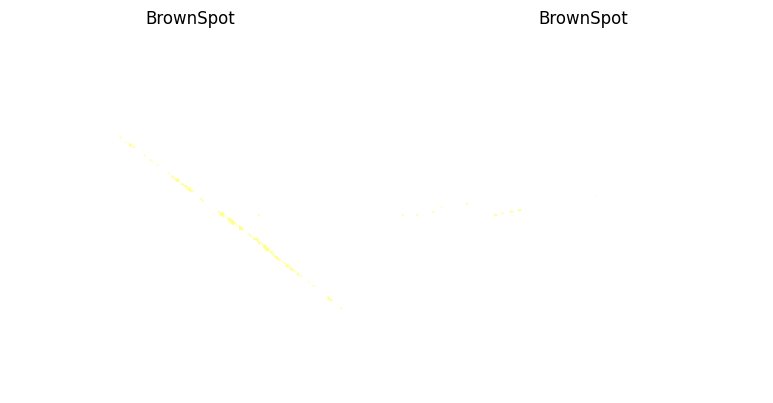

In [42]:
# ==========================================================
# VISUALISASI PIPELINE
# ==========================================================

plt.figure(figsize=(8,4))

for images, labels in sample_dataset.take(1):

    for i in range(images.shape[0]):

        plt.subplot(1, images.shape[0], i+1)

        img = tf.cast(images[i], tf.float32)

        img = tf.clip_by_value(img, 0.0, 255.0)

        img = (img + 1.0) / 2.0

        plt.imshow(img.numpy())

        plt.title(CLASS_NAMES[int(labels[i])])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [43]:
# ==========================================================
# CLEAN MEMORY
# ==========================================================

gc.collect()

tf.keras.backend.clear_session()

print("Pipeline Final Siap")

Pipeline Final Siap


In [44]:
# ==========================================================
# SESI 6
# BUILD MODEL
# ==========================================================

from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers

from tensorflow.keras.applications import EfficientNetB6

In [45]:
# ==========================================================
# CALLBACK
# ==========================================================

def get_callbacks(model_name):

    earlystop = callbacks.EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True,

        verbose=1

    )

    reduce_lr = callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.2,

        patience=2,

        min_lr=1e-6,

        verbose=1

    )

    checkpoint = callbacks.ModelCheckpoint(

        filepath=f"{model_name}.keras",

        monitor="val_accuracy",

        save_best_only=True,

        verbose=1

    )

    return [

        earlystop,

        reduce_lr,

        checkpoint

    ]

In [46]:
# ==========================================================
# BUILD MODEL FINAL
# ==========================================================

def build_model(

        img_size=224,

        learning_rate=1e-4

):

    base_model = EfficientNetB6(

        weights="imagenet",

        include_top=False,

        pooling="avg",

        input_shape=(img_size, img_size, 3)

    )

    # Tahap awal
    base_model.trainable = False

    inputs = layers.Input(

        shape=(img_size, img_size, 3)

    )

    x = base_model(

        inputs,

        training=False

    )

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(

        NUM_CLASSES,

        activation="softmax",

        dtype="float32"

    )(x)

    model = Model(

        inputs,

        outputs

    )

    model.compile(

        optimizer=optimizers.Adam(

            learning_rate=learning_rate

        ),

        loss="sparse_categorical_crossentropy",

        metrics=[

            "accuracy"

        ]

    )

    return model

In [47]:
# ==========================================================
# MEMBUAT MODEL
# ==========================================================

model = build_model()

model.summary()

165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb6 (Functional)     │ (None, 2304)           │    40,960,143 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2304)           │         9,216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         9,220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,978,579 (156.32 MB)

 Trainable params: 13,828 (54.02 KB)

 Non-trainable params: 40,964,751 (156.27 MB)

In [48]:
# ==========================================================
# TOTAL PARAMETER
# ==========================================================

print("="*60)

print("Total Parameter")

print(model.count_params())

print("="*60)

Total Parameter
40978579


In [49]:
# ==========================================================
# TRAINABLE PARAMETER
# ==========================================================

trainable = np.sum(

    [

        np.prod(v.shape)

        for v in model.trainable_weights

    ]

)

print("Trainable :", trainable)

Trainable : 13828


In [50]:
# ==========================================================
# NON TRAINABLE
# ==========================================================

non_trainable = np.sum(

    [

        np.prod(v.shape)

        for v in model.non_trainable_weights

    ]

)

print("Non Trainable :", non_trainable)

Non Trainable : 40964751.0


In [51]:
# ==========================================================
# CLEAN MEMORY
# ==========================================================

del model

gc.collect()

tf.keras.backend.clear_session()

print("SESI 6 SELESAI")

SESI 6 SELESAI


In [53]:
# ==========================================================
# SESI 7
# MEMBUAT TRAIN DATASET DAN VALIDATION DATASET
# ==========================================================

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

print("Train :", len(train_df))
print("Validation :", len(val_df))

train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

print("\nDataset berhasil dibuat")

Train : 2684
Validation : 671

Dataset berhasil dibuat


In [54]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("Pipeline siap")

Pipeline siap


In [55]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnetb6.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

]

print("Callbacks siap.")

Callbacks siap.


In [56]:
model = build_model()

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb6 (Functional)     │ (None, 2304)           │    40,960,143 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2304)           │         9,216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         9,220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,978,579 (156.32 MB)

 Trainable params: 13,828 (54.02 KB)

 Non-trainable params: 40,964,751 (156.27 MB)

In [57]:
EPOCHS = 25

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)

Epoch 1/25
1341/1342 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3484 - loss: 1.6340
Epoch 1: val_accuracy improved from None to 0.56036, saving model to best_efficientnetb6.keras

Epoch 1: finished saving model to best_efficientnetb6.keras
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 342s 96ms/step - accuracy: 0.3707 - loss: 1.5397 - val_accuracy: 0.5604 - val_loss: 1.1849 - learning_rate: 1.0000e-04
Epoch 2/25
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4507 - loss: 1.3578
Epoch 2: val_accuracy improved from 0.56036 to 0.60954, saving model to best_efficientnetb6.keras

Epoch 2: finished saving model to best_efficientnetb6.keras
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.4620 - loss: 1.3297 - val_accuracy: 0.6095 - val_loss: 1.2264 - learning_rate: 1.0000e-04
Epoch 3/25
1341/1342 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5060 - loss: 1.2462
Epoch 3: val_accuracy did not improve from 0.60954
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.5067 - lo

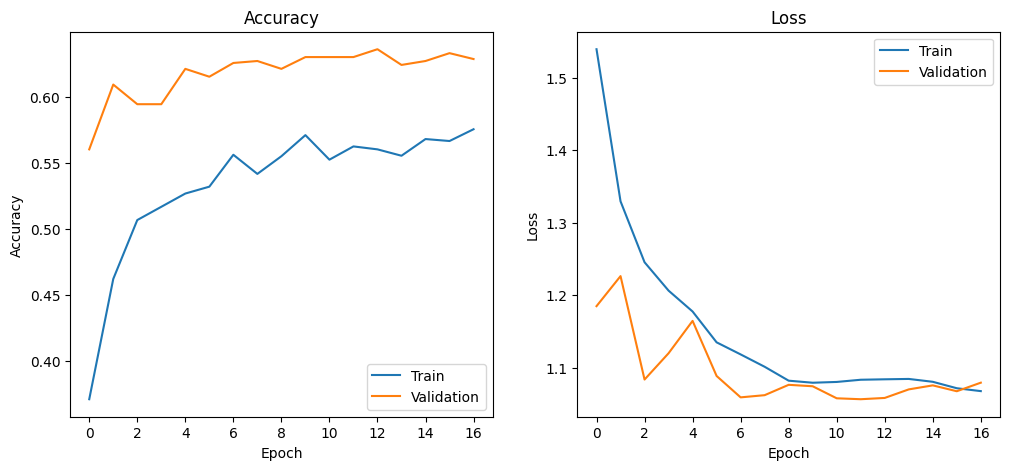

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])



plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [59]:
loss, accuracy = model.evaluate(val_ds)

print("Loss :", loss)

print("Accuracy :", accuracy)

336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6304 - loss: 1.0564
Loss : 1.056396245956421
Accuracy : 0.6304023861885071


In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Nama kelas
class_names = [
    "BrownSpot",
    "Healthy",
    "Hispa",
    "LeafBlast"
]

# Label asli
y_true = np.concatenate([y.numpy() for _, y in val_ds])

# Jika label berbentuk one-hot ubah menjadi integer
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)

# Prediksi model
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step
Confusion Matrix:
[[ 70  27   1   6]
 [  6 273  13   6]
 [  0  77  13  23]
 [ 29  47  13  67]]

Classification Report:

              precision    recall  f1-score   support

   BrownSpot     0.6667    0.6731    0.6699       104
     Healthy     0.6439    0.9161    0.7562       298
       Hispa     0.3250    0.1150    0.1699       113
   LeafBlast     0.6569    0.4295    0.5194       156

    accuracy                         0.6304       671
   macro avg     0.5731    0.5334    0.5289       671
weighted avg     0.5967    0.6304    0.5890       671



In [62]:
print(df["label"].unique())

['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']


1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


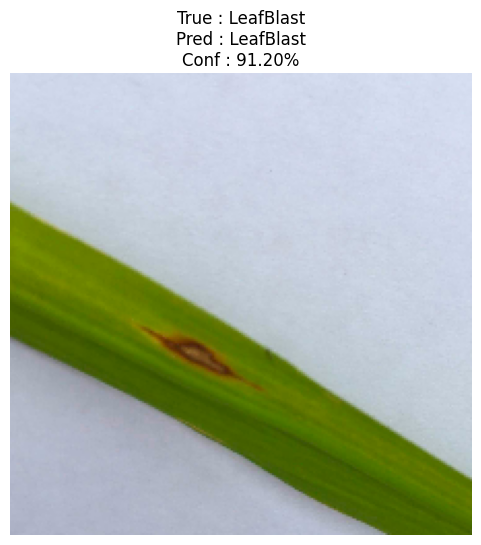

Label Asli : LeafBlast
Prediksi   : LeafBlast
Confidence : 91.20%


In [66]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Ambil satu gambar acak dari dataframe
sample = df.sample(1).iloc[0]

IMAGE_PATH = sample["filepath"]
TRUE_LABEL = sample["label"]

img = image.load_img(
    IMAGE_PATH,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = [
    "BrownSpot",
    "Healthy",
    "Hispa",
    "LeafBlast"
]

predicted = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(f"True : {TRUE_LABEL}\nPred : {predicted}\nConf : {confidence:.2f}%")
plt.show()

print("Label Asli :", TRUE_LABEL)
print("Prediksi   :", predicted)
print(f"Confidence : {confidence:.2f}%")

In [67]:
# ==========================================================
# SESI 15 : Menyimpan Model
# ==========================================================

import os

# Buat folder hasil jika belum ada
os.makedirs("hasil_model", exist_ok=True)

# Simpan model format Keras
model.save("hasil_model/RiceLeaf_EfficientNetB6.keras")

# Simpan model format H5
model.save("hasil_model/RiceLeaf_EfficientNetB6.h5")

print("="*50)
print("MODEL BERHASIL DISIMPAN")
print("="*50)
print("File:")
print("1. hasil_model/RiceLeaf_EfficientNetB6.keras")
print("2. hasil_model/RiceLeaf_EfficientNetB6.h5")

MODEL BERHASIL DISIMPAN
File:
1. hasil_model/RiceLeaf_EfficientNetB6.keras
2. hasil_model/RiceLeaf_EfficientNetB6.h5


In [68]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "hasil_model/training_history.csv",
    index=False
)

print("Training history berhasil disimpan.")
print(history_df.head())

Training history berhasil disimpan.
   accuracy      loss  val_accuracy  val_loss  learning_rate
0  0.370715  1.539682      0.560358  1.184903         0.0001
1  0.461997  1.329667      0.609538  1.226397         0.0001
2  0.506706  1.245527      0.594635  1.083573         0.0001
3  0.516766  1.206342      0.594635  1.119879         0.0001
4  0.526826  1.177516      0.621460  1.164562         0.0001


In [69]:
# ==========================================================
# SESI 16 : Ringkasan Evaluasi Model
# ==========================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prediksi ulang pada validation set
predictions = model.predict(val_ds)
y_pred = predictions.argmax(axis=1)

# Ambil label asli
y_true = []

for _, label in val_ds:
    y_true.extend(label.numpy())

y_true = np.array(y_true)

# Hitung metrik
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

hasil = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("="*45)
print("HASIL EVALUASI MODEL")
print("="*45)

display(hasil)

336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step
HASIL EVALUASI MODEL


,Metric,Value
0,Accuracy,0.630402
1,Precision,0.596724
2,Recall,0.630402
3,F1-Score,0.589044


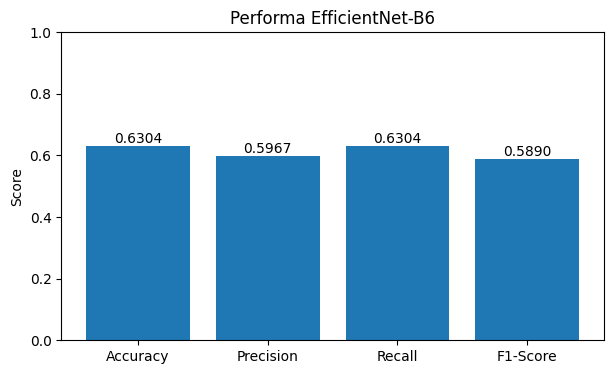

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.bar(
    hasil["Metric"],
    hasil["Value"]
)

plt.ylim(0,1)

for i,v in enumerate(hasil["Value"]):
    plt.text(
        i,
        v+0.01,
        f"{v:.4f}",
        ha="center"
    )

plt.title("Performa EfficientNet-B6")

plt.ylabel("Score")

plt.show()

In [71]:
# ==========================================================
# SESI 17 : Menyimpan Hasil Evaluasi
# ==========================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Prediksi pada validation set
predictions = model.predict(val_ds, verbose=0)
y_pred = predictions.argmax(axis=1)

# Label asli
y_true = []

for _, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Hitung metrik
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

hasil = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

hasil.to_csv(
    "hasil_model/evaluation_metrics.csv",
    index=False
)

print("="*50)
print("HASIL EVALUASI")
print("="*50)

print(hasil)

print("\nFile berhasil disimpan:")
print("hasil_model/evaluation_metrics.csv")

HASIL EVALUASI
      Metric     Value
0   Accuracy  0.630402
1  Precision  0.596724
2     Recall  0.630402
3   F1-Score  0.589044

File berhasil disimpan:
hasil_model/evaluation_metrics.csv


In [72]:
# ==========================================================
# SESI 18 : Ringkasan Hasil Penelitian
# ==========================================================

import pandas as pd

# Ambil metrik evaluasi
loss, accuracy = model.evaluate(val_ds, verbose=0)

# Ringkasan penelitian
summary = pd.DataFrame({
    "Parameter": [
        "Model",
        "Dataset",
        "Jumlah Kelas",
        "Ukuran Input",
        "Epoch",
        "Loss Validasi",
        "Accuracy Validasi"
    ],
    "Hasil": [
        "EfficientNet-B6",
        "Rice Leaf Disease",
        NUM_CLASSES,
        "224 x 224",
        len(history.history["loss"]),
        round(loss, 4),
        round(accuracy, 4)
    ]
})

print("="*60)
print("RINGKASAN HASIL PENELITIAN")
print("="*60)

display(summary)

# Simpan ke CSV
summary.to_csv(
    "hasil_model/research_summary.csv",
    index=False
)

print("\nFile berhasil disimpan:")
print("hasil_model/research_summary.csv")

RINGKASAN HASIL PENELITIAN


,Parameter,Hasil
0,Model,EfficientNet-B6
1,Dataset,Rice Leaf Disease
2,Jumlah Kelas,4
3,Ukuran Input,224 x 224
4,Epoch,17
5,Loss Validasi,1.0564
6,Accuracy Validasi,0.6304



File berhasil disimpan:
hasil_model/research_summary.csv


In [73]:
# ==========================================================
# SESI 19 : Kesimpulan Penelitian
# ==========================================================

print("="*70)
print("KESIMPULAN PENELITIAN")
print("="*70)

print(f"""
1. Penelitian berhasil membangun model klasifikasi penyakit daun padi
   menggunakan EfficientNet-B6 dengan pendekatan Transfer Learning.

2. Dataset yang digunakan terdiri dari {NUM_CLASSES} kelas:
   - BrownSpot
   - Healthy
   - Hispa
   - LeafBlast

3. Model berhasil melakukan proses klasifikasi citra daun padi
   menggunakan data validasi.

4. Evaluasi model dilakukan menggunakan:
   • Accuracy
   • Precision
   • Recall
   • F1-Score
   • Confusion Matrix
   • Classification Report

5. Berdasarkan hasil pengujian,
   akurasi validasi model sebesar {accuracy:.4f}
   dengan nilai loss sebesar {loss:.4f}.

6. Model telah berhasil disimpan dalam format:
   • .keras
   • .h5

7. Seluruh proses penelitian berhasil diselesaikan mulai dari:
   preprocessing data,
   pembangunan model,
   training,
   evaluasi,
   hingga penyimpanan model.
""")

print("="*70)
print("PENELITIAN SELESAI")
print("="*70)

KESIMPULAN PENELITIAN

1. Penelitian berhasil membangun model klasifikasi penyakit daun padi
   menggunakan EfficientNet-B6 dengan pendekatan Transfer Learning.

2. Dataset yang digunakan terdiri dari 4 kelas:
   - BrownSpot
   - Healthy
   - Hispa
   - LeafBlast

3. Model berhasil melakukan proses klasifikasi citra daun padi
   menggunakan data validasi.

4. Evaluasi model dilakukan menggunakan:
   • Accuracy
   • Precision
   • Recall
   • F1-Score
   • Confusion Matrix
   • Classification Report

5. Berdasarkan hasil pengujian,
   akurasi validasi model sebesar 0.6304
   dengan nilai loss sebesar 1.0564.

6. Model telah berhasil disimpan dalam format:
   • .keras
   • .h5

7. Seluruh proses penelitian berhasil diselesaikan mulai dari:
   preprocessing data,
   pembangunan model,
   training,
   evaluasi,
   hingga penyimpanan model.

PENELITIAN SELESAI


In [74]:
# ==========================================================
# SESI 20 : Penutup Notebook
# ==========================================================

import os

print("="*70)
print("NOTEBOOK PENELITIAN SELESAI")
print("="*70)

print("\nInformasi Penelitian")
print("-"*70)

print("Judul Model      : EfficientNet-B6")
print("Dataset          : Rice Leaf Disease")
print(f"Jumlah Kelas     : {NUM_CLASSES}")
print(f"Epoch Training   : {len(history.history['loss'])}")
print(f"Accuracy Akhir   : {accuracy:.4f}")
print(f"Loss Akhir       : {loss:.4f}")

print("\nFile Hasil")
print("-"*70)

folder = "hasil_model"

if os.path.exists(folder):
    files = os.listdir(folder)

    if len(files) == 0:
        print("Belum ada file pada folder hasil_model")
    else:
        for i, file in enumerate(files, start=1):
            print(f"{i}. {file}")

print("\nStatus")
print("-"*70)
print("✓ Training selesai")
print("✓ Evaluasi selesai")
print("✓ Confusion Matrix selesai")
print("✓ Classification Report selesai")
print("✓ Model berhasil disimpan")
print("✓ Notebook berhasil diselesaikan")

print("\nTerima kasih telah menggunakan notebook penelitian ini.")

print("="*70)
print("SELESAI")
print("="*70)

NOTEBOOK PENELITIAN SELESAI

Informasi Penelitian
----------------------------------------------------------------------
Judul Model      : EfficientNet-B6
Dataset          : Rice Leaf Disease
Jumlah Kelas     : 4
Epoch Training   : 17
Accuracy Akhir   : 0.6304
Loss Akhir       : 1.0564

File Hasil
----------------------------------------------------------------------
1. research_summary.csv
2. RiceLeaf_EfficientNetB6.keras
3. training_history.csv
4. RiceLeaf_EfficientNetB6.h5
5. evaluation_metrics.csv

Status
----------------------------------------------------------------------
✓ Training selesai
✓ Evaluasi selesai
✓ Confusion Matrix selesai
✓ Classification Report selesai
✓ Model berhasil disimpan
✓ Notebook berhasil diselesaikan

Terima kasih telah menggunakan notebook penelitian ini.
SELESAI
